# 🔥 Building Micrograd: A PyTorch-like Autograd Engine
> **Status:** Active | **Topic:** Deep Learning | **Inspiration:** [Andrej Karpathy](https://github.com/karpathy/micrograd)

## 🎯 Project Overview
This notebook documents the construction of a **scalar-valued autograd engine** from first principles. The goal is to demystify the "black box" of Deep Learning frameworks by rebuilding the core machinery of **PyTorch** from scratch.

## 🧠 Learning Objectives
* **Reverse-Mode Autodiff:** Implementing backpropagation manually to understand gradient flow.
* **Computational Graphs:** Visualizing how operations are chained and how derivatives are calculated.
* **Neural Network Primitives:** Building `Neurons`, `Layers`, and `MLPs` using only raw math and Python.

---

In [1]:
import math
import random
from graphviz import Digraph

In [2]:
class Tensor:
    """
    The fundamental building block of the Autograd engine.
    
    Arguments:
        data: The scalar value to be stored.
        _children: The parent nodes in the graph. Defaults to () (tuple) 
        because tuples are immutable, preventing the 'mutable default arg' bug.
        _op: Internal label for the operation type (e.g., '+'). 
        Prefixed with '_' to signal it is for internal use only (Encapsulation),
        not to prevent modification.
    """
    def __init__(self, data, _children = (), _op = "", label = ""):
        self.data = data
        self.gradient = 0
        self._backward = lambda: None
        self._child_node = set(_children) # set to ensure that the children nodes are unique
        self._op = _op # To store the operation carried out
        self.label = label # for displaying the name of the node in graph

    def __repr__(self):
        return f"data = {self.data}"    
    
    # Overloading the "+" and "*" operator to add and multiply the data of two different objects using simple syntax
    def __add__(self, other):
        other = other if isinstance(other, Tensor) else Tensor(other)
        out = Tensor(self.data + other.data, (self, other), _op = "+")

        
        def _backward():
            # Why +=? Because when same object is used twice in multiple operations, the gradients are overwritten, 
            # += makes sure that the gradients aren't overwritten but they are added together.
            self.gradient += 1.0 * out.gradient
            other.gradient += 1.0 * out.gradient
        
        out._backward = _backward
        
        return out
    # a.__add__(b)

    def __radd__(self, other): #other + self
        return self + other
    
    def __mul__(self, other):
        other = other if isinstance(other, Tensor) else Tensor(other)
        out = Tensor(self.data * other.data, (self, other), _op = "*")
        def _backward():
            self.gradient += other.data * out.gradient
            other.gradient += self.data * out.gradient
        
        out._backward = _backward
        return out
    # a.__mul__(b)

    def __rmul__(self, other): # other * self
        return self * other

    def backward_propagation(self):
        # Maintaining Topological Order
            topological_order = []
            visited = set()

            def build_topological_order(root):
                if root not in visited:
                    visited.add(root)

                    for child in root._child_node:
                        build_topological_order(child)        
                    topological_order.append(root)

            build_topological_order(self)

            self.gradient = 1.0
            for node in reversed(topological_order):
                node._backward()

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "Supports int and float powers"
        out = Tensor(self.data ** other, (self,), f"**{other}")

        def _backward():
            self.gradient += other * (self.data ** (other - 1)) * out.gradient
        out._backward = _backward

        return out

    def __neg__(self):
        return self * -1
    
    def __sub__(self, other):
        return self + (-other)
    
    def __rsub__(self, other):
        return other + (-self)


    #tanh for now but can be changed with sigmoid and other with a slight tweak in the return statement
    def activation_function(self):
        x = self.data
        res = (math.exp(2 * x) - 1) / (math.exp(2 * x) + 1)
        out = Tensor(res, (self, ), "tanh")

        def _backward():
            self.gradient += (1 - res ** 2) * out.gradient
        
        out._backward = _backward

        return out

In [3]:
def trace(root):
    """
    Builds the computational graph starting from the output node (root).

    Returns:
        nodes: set of all Tensor objects involved in the computation
        edges: set of (child, parent) tuples representing dependencies
                Meaning: parent depends on child  ==>  child → parent
    """
    nodes, edges = set(), set()
    def build_graph(v):
        """
        Recursively traverses the graph backwards (from outputs to inputs).
        """
        if v not in nodes:
            nodes.add(v)

            for child in v._child_node:
                edges.add((child,v))
                build_graph(child)
    
    build_graph(root)
    return nodes, edges

def draw_dot(root, format = "svg", rankdir = "LR"):
    """
    Visualizes the computational graph using Graphviz.

    Each Tensor is represented by:
        - a value node (rectangle)
        - an operation node (circle), if applicable

    Graph flow:
        child value → operation → parent value
    """
    nodes, edges = trace(root)

    #Initialize Graphviz directed graph
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir})

    # Draw all Tensor value nodes
    for n in nodes:
        # Unique identifier for the Tensor (memory address)
        uid = str(id(n))

        # Draw the value node (rectangle) and Uses __repr__ of Tensor
        dot.node(name=uid, label = "{%s | %.4f | gradient %.4f }" % (n.label, n.data, n.gradient), shape='record')

        # If this Tensor was created by an operation, draw the op node
        if n._op:

            # Operation node (unique per Tensor)
            dot.node(name=uid + n._op, label=n._op)

            # Edge: operation -> value
            # Meaning: the operation produces this value
            dot.edge(uid + n._op, uid)    

    for n1, n2 in edges:
        # Edge: child value -> parent operation
        # Meaning: child participates in parent's operation
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)


    return dot

In [4]:
class Neuron:
    def __init__(self, no_inputs):
        # To initialize weights for the number of inputs of a neuron
        self.w = [Tensor(random.uniform(-1, 1)) for _ in range(no_inputs)]
        self.b = Tensor(random.uniform(-1,1))
    
    def __call__(self, x):
        activation = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        output = activation.activation_function()
        return output
    
    def parameters(self):
        return self.w + [self.b]
    
class Layer:
    # no_inputs: Number of inputs per neuron
    # no_out: Number of neurons in the layer
    def __init__(self, no_inputs, no_out):
        self.neurons = [Neuron(no_inputs) for _ in range(no_out)]
    
    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs

    def parameters(self):
        return [neuron_parameters for neuron in self.neurons for neuron_parameters in neuron.parameters()]
    

class MultiLayerPerceptron:
    def __init__(self, no_inputs, no_out):
        size = [no_inputs] + no_out
        self.layers = [Layer(size[i], size[i+1]) for i in range(len(no_out))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [layer_parameters for layer in self.layers for layer_parameters in layer.parameters()]

In [5]:
mlp = MultiLayerPerceptron(2, [4,4,4,1])

In [6]:
x_input = [
    [0, 0], 
    [0, 1],
    [1, 0],
    [1, 1]
]

y_out = [0, 1, 1, 1]

In [7]:
epochs = 50
learning_rate = 0.07

for epoch in range(epochs):
    ypred = [mlp(x) for x in x_input]
    loss = sum((yout[0] - y_ground_truth)**2 for y_ground_truth, yout in zip(y_out, ypred))

    for params in mlp.parameters():
        params.gradient = 0.0
    loss.backward_propagation()

    for params in mlp.parameters():
        params.data  += -learning_rate * params.gradient

    print(f"Step {epoch}: loss = {loss.data}")

Step 0: loss = 0.7026716543899998
Step 1: loss = 0.6167940072472765
Step 2: loss = 0.5321157183672471
Step 3: loss = 0.4655359744800321
Step 4: loss = 0.40046199215240136
Step 5: loss = 0.33455230079364956
Step 6: loss = 0.2720443118146866
Step 7: loss = 0.21659935999079727
Step 8: loss = 0.1701549425056806
Step 9: loss = 0.13291678095805662
Step 10: loss = 0.10397802998052277
Step 11: loss = 0.08195346159391675
Step 12: loss = 0.06537371320220083
Step 13: loss = 0.05292343810069058
Step 14: loss = 0.04352807929490872
Step 15: loss = 0.036369824764365594
Step 16: loss = 0.03084502123893045
Step 17: loss = 0.02652089849394638
Step 18: loss = 0.02308637248996314
Step 19: loss = 0.020320102105065196
Step 20: loss = 0.018061463903029613
Step 21: loss = 0.016194490437650526
Step 22: loss = 0.014633002755539798
Step 23: loss = 0.013313445407455686
Step 24: loss = 0.012187243681419413
Step 25: loss = 0.011217824667808749
Step 26: loss = 0.010376425421114133
Step 27: loss = 0.00964102827461514

In [8]:
ypred

[[data = -0.2412061649464457],
 [data = 0.9307118816640712],
 [data = 0.9306839413768212],
 [data = 0.9910956335805288]]

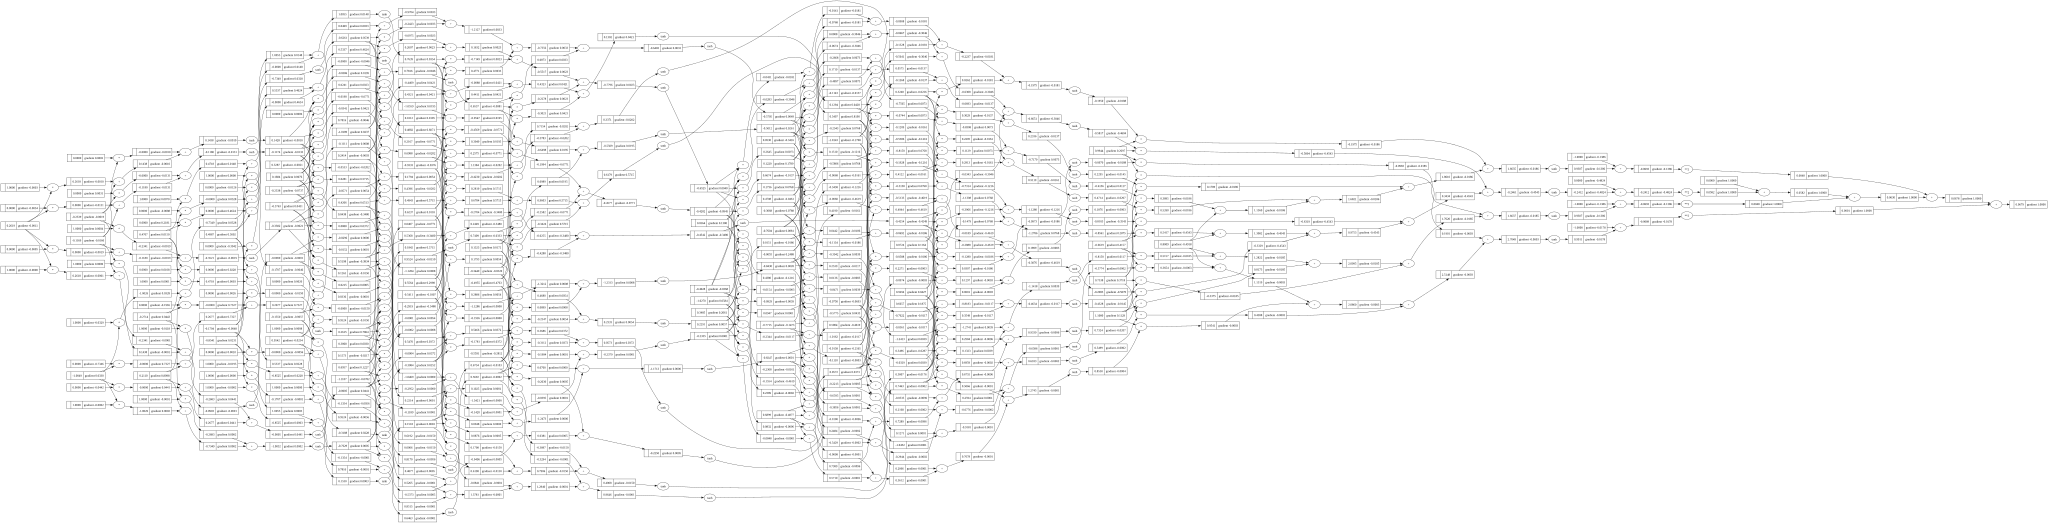

In [9]:
draw_dot(loss)